  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

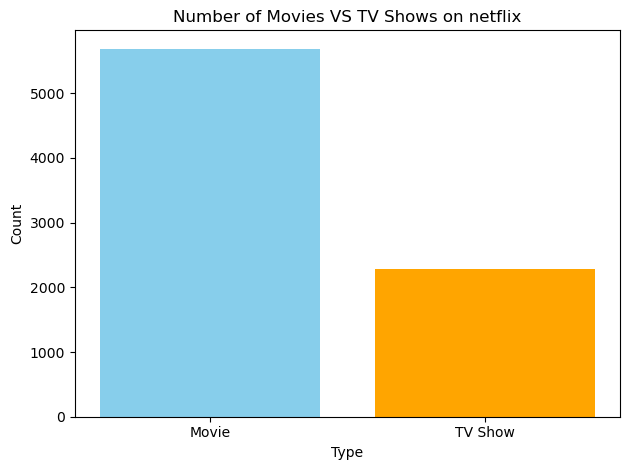

rating
TV-MA       2931
TV-14       1930
R            788
TV-PG        773
PG-13        482
PG           281
TV-Y7        236
TV-Y         227
TV-G         190
NR            80
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



#=====================
# DATA  Understanding
#=====================

df = pd.read_csv(r"C:\Users\anshi\Downloads\netflix_titles.csv.zip")
df.to_csv(r"C:\Users\anshi\Downloads\netflix_titles.csv")
print(df.head())
print(df.columns)
print(df.info())
print(df.duplicated().sum())
print(df.isnull().sum())

#===================
# DATA Cleaning 
#===================

df = df.dropna(subset=['country', 'duration', 'rating'])

#=======================
# DATA Visualization
#=======================

# 1 - Bar Chart for visualizing Number of movies and Tv Shows 
# ---------------------------------------------------------------
type_counts = df ['type'].value_counts()  #---->how many times different rows appear ,like movies=2056, tv shows = 45467 times 
plt.bar(type_counts.index, type_counts.values ,color=['skyblue','orange'])
plt.title('Number of Movies VS TV Shows on netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvShows.png')
plt.show()

# 2 - Pie Chart for visualizing thr rating of the content 
#----------------------------------------------------------------
rating_count= df ['rating'].value_counts()
print(rating_count)

plt.figure(figsize=(8,6))
plt.pie(rating_count , labels= rating_count.index , autopct = '%1.1f%%', startangle = 90)
plt.title('Percentage of Content Rating')
plt.tight_layout()
plt.savefig('Content_rating_pie.png')
plt.show()


# 3 - Visualizatin of Movie type data  using histogram 
#----------------------------------------------------------------
movies_df = df[df['type'] == 'Movie'].copy() 
movies_df['duration'] = movies_df['duration'].str.replace('min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movies_df['duration'], bins=30, color ='pink', edgecolor='black')
plt.title('Duration of Movies')
plt.xlabel('Duration(minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('Movie_duration_histogram.png')
plt.show()

# 4 - Visualization of no. of shows VS release year using Scatter plot 
#----------------------------------------------------------------------
release_count = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_count.index, release_count.values, color='red')
plt.title('Release year VS number of shows')
plt.xlabel('Release year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()


# 5 - Top ten countries with hiighest number of Shows 
#--------------------------------------------------------------------
country_count = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_count.index, country_count.values , color = 'teal')
plt.title('Top 10 countries by number of shows')
plt.xlabel('Number of Shows')
plt.ylabel('countries')
plt.tight_layout()
plt.savefig('Top_10_Countries.png')
plt.show()

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig , ax = plt.subplots(1,2,figsize=(12,5))

#=========================
# FIRST SUBPLOT
#=========================
ax[0].plot(content_by_year.index, content_by_year['Movie'], color = 'Blue')
ax[0].set_title('Movies Releasesd per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')


#=========================
# Second SUBPLOT
#=========================
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color = 'orange')
ax[1].set_title('TV Sows Releasesd per year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of Movies')

fig.suptitle('Comparision of Movies and TV shows release over years')

plt.tight_layout()
plt.savefig('movies_tv_shows_comparision.png')
plt.show()